<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/PredictiveAnalysis18thOct2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Analysis**
It means examining data or informations carefully to understand some patterns, relationship or any insights that help us to make some decision

**It is divided into basic parts:**
1. **Descriptive Analysis:** When we talk about what happened?
    * It basically tries to summarize the past data.
    * Example: Our sales increased by 10% in last quater
2. **Prescriptive Analysis:** When we talk about the what we should do about the concern
    * It allow us to suggest best action to take for desired outcome
    * Example: How much to increase in ad spend in social media to boost future sale.
3. **Diagnostic Anlysis:** When we talk about why did something happen?
    * it gets the cause behind the results
    * Example: House price based on land sqft
4. **Predicitve Anlysis:** It tells what will happen next
    * It basically uses the past data + We use some statistical model or Machine learning model to forecast the future trends.
    * In Next month our sales will increase upto 15%

##**How we can setup a production grade preprocessing Pipeline**

**Loading a sample data**

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df = sns.load_dataset('titanic')

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.sibsp.value_counts()

,count
sibsp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


**Let's try to merge the family size**

In [ ]:
df['family_size'] = df['sibsp'] + df['parch']

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


In [ ]:
df.family_size.value_counts()

,count
family_size,
0,537
1,161
2,102
3,29
5,22
4,15
6,12
10,7
7,6


In [ ]:
df = df.drop(['sibsp','parch','deck','embark_town','alive'], axis = 1)

In [ ]:
df.head()

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,alone,family_size
0,0,3,male,22.0,7.2500,S,Third,man,True,False,1
1,1,1,female,38.0,71.2833,C,First,woman,False,False,1
2,1,3,female,26.0,7.9250,S,Third,woman,False,True,0
3,1,1,female,35.0,53.1000,S,First,woman,False,False,1
4,0,3,male,35.0,8.0500,S,Third,man,True,True,0


**Define Features and Target column**

In [ ]:
x = df.drop('survived',axis = 1)
y = df['survived']

In [ ]:
x

,pclass,sex,age,fare,embarked,class,who,adult_male,alone,family_size
0,3,male,22.0,7.2500,S,Third,man,True,False,1
1,1,female,38.0,71.2833,C,First,woman,False,False,1
2,3,female,26.0,7.9250,S,Third,woman,False,True,0
3,1,female,35.0,53.1000,S,First,woman,False,False,1
4,3,male,35.0,8.0500,S,Third,man,True,True,0
...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,Second,man,True,True,0
887,1,female,19.0,30.0000,S,First,woman,False,True,0
888,3,female,NaN,23.4500,S,Third,woman,False,False,3
889,1,male,26.0,30.0000,C,First,man,True,True,0


In [ ]:
y

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [ ]:
print(f'Train shape: {x_train.shape}')
print(f'Test shape: {x_test.shape}')

Train shape: (712, 10)
Test shape: (179, 10)


**Build Pipeline**

Instead of manually cleaning data step by step which can be messy or risky, we build something called pipeline to handle all of it automatically.
* It prevents the data leakage
* It keeps our code clean and ready for the production

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
import numpy as np

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   fare         891 non-null    float64 
 5   embarked     889 non-null    object  
 6   class        891 non-null    category
 7   who          891 non-null    object  
 8   adult_male   891 non-null    bool    
 9   alone        891 non-null    bool    
 10  family_size  891 non-null    int64   
dtypes: bool(2), category(1), float64(2), int64(3), object(3)
memory usage: 58.6+ KB


In [ ]:
print(df.select_dtypes(include=np.number).columns)
print(df.select_dtypes(exclude=np.number).columns)

Index(['survived', 'pclass', 'age', 'fare', 'family_size'], dtype='object')
Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'alone'], dtype='object')


In [ ]:
numerical_features = ['pclass', 'age', 'fare', 'family_size']
categorical_features = ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone']

**Numerical preprocessing**
* Replace missing values with the **median**
* Scale them using **StandardScalar** -> ALl columns will have same range

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

**Categorical Preprocessing**
* Replace the missing values with the Mode**
* Convert categories into number using OneHot encoder

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

**Combine Both Transformers into one single preprocess (transformer)**

We are using columnTransformer:
* numericalTransfomer - Numerical Feature
* CategoricalTransformer - Categorical Features

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num',numeric_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

**Let's create Full Machine Learning Pipeline**
* We got **preprocessor**
* We will chain it with RandomForest()

It will convert the pipeline into end-to-end pipeline that handles everything automatically

In [ ]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

**Train the Entire Pipeline**

Now we will just use on `.fit()` -> it calls trains both preprocessing and the model together

In [ ]:
model_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'fare',
                                                   'family_size']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked', 'class',
                                                   'who', 'adult_male',
                                                   'alone'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

**Evaluate Model performance**

In [ ]:
predictions = model_pipeline.predict(x_test)

In [ ]:
predictions

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1])

In [ ]:
print(f'Accuracy with the pipeline: {accuracy_score(y_test,predictions):.2f}')

Accuracy with the pipeline: 0.84


**Give some new data**

In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'fare', 'embarked', 'class', 'who',
       'adult_male', 'alone', 'family_size'],
      dtype='object')

In [ ]:
df.head()

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,alone,family_size
0,0,3,male,22.0,7.2500,S,Third,man,True,False,1
1,1,1,female,38.0,71.2833,C,First,woman,False,False,1
2,1,3,female,26.0,7.9250,S,Third,woman,False,True,0
3,1,1,female,35.0,53.1000,S,First,woman,False,False,1
4,0,3,male,35.0,8.0500,S,Third,man,True,True,0


In [ ]:
new_passanger = pd.DataFrame([{
    'pclass': 1, 'sex': 'female', 'age': 35, 'fare': 80, 'embarked': 'S', 'class':'First', 'who': 'woman',
       'adult_male': False, 'alone': False, 'family_size': 2
}])

In [ ]:
predictNew = model_pipeline.predict(new_passanger)
print(f'Prediction for the new Passenger: {'Survived' if predictNew[0] == 1 else 'Did not Survived'}')

Prediction for the new Passenger: Survived


**We can now save our Pipeline**

In [ ]:
import joblib

# we will save the pipeline for future use

joblib.dump(preprocessor, 'savedPipeline.pkl')
print('preprocessor pipline is now saved')

preprocessor pipline is now saved


##**Optuna and XGBoost**

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 21.9 MB/s eta 0:00:00


In [ ]:
preprocessor = joblib.load('savedPipeline.pkl')

In [ ]:
import xgboost as xgb
import optuna
from sklearn.model_selection import cross_val_score

In [ ]:
def objective(trial):
  # We will define search space
  params = {
      'n_estimators': trial.suggest_int('n_estimators',100,1000),
      'max_depth': trial.suggest_int('max_depth',3,10),
      'learning_rate': trial.suggest_float('learning_rate',0.01,0.3),
      'subsample': trial.suggest_float('subsample',0.6,1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree',0.6,1.0),
      'gamma': trial.suggest_float('gamma',0,5),
  }

  # We built our model
  xgb_model = xgb.XGBClassifier(
      objective = 'binary:logistic',
      eval_metrics = 'logloss',
      use_label_encoder = False,
      random_state = 42,
      **params
  )

  # Create Pipeline (preprocessor + model)
  full_pipeline = Pipeline(steps=[
      ('preprocessor',preprocessor),
      ('classifier',xgb_model)
  ])

  score = cross_val_score(full_pipeline,x_train,y_train,n_jobs =-1,cv = 3,scoring='accuracy')
  return score.mean()

**Now we will run our Optuna Optimization**

We will tell optuna:
* maximize accuracy
* Run for 50 trials (you can increasre it)

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=100)

[I 2025-10-18 06:55:49,387] A new study created in memory with name: no-name-d6baa306-b4b0-4250-96e8-243db631895f
[I 2025-10-18 06:55:49,736] Trial 0 finished with value: 0.8286529801794136 and parameters: {'n_estimators': 838, 'max_depth': 6, 'learning_rate': 0.06932086979302106, 'subsample': 0.7271444423852338, 'colsample_bytree': 0.8019737266239458, 'gamma': 4.930658374633611}. Best is trial 0 with value: 0.8286529801794136.
[I 2025-10-18 06:55:50,031] Trial 1 finished with value: 0.8272406008817029 and parameters: {'n_estimators': 672, 'max_depth': 10, 'learning_rate': 0.05519728853096337, 'subsample': 0.7132831153395528, 'colsample_bytree': 0.9419172825039421, 'gamma': 4.210184701777831}. Best is trial 0 with value: 0.8286529801794136.
[I 2025-10-18 06:55:50,452] Trial 2 finished with value: 0.8146237397912751 and parameters: {'n_estimators': 997, 'max_depth': 8, 'learning_rate': 0.08027123489715161, 'subsample': 0.8603552470699263, 'colsample_bytree': 0.8084970974752159, 'gamma':

**We will review the best results**

In [ ]:
print(f'The besst Trial Accuracy: {study.best_value:.4f}')

The besst Trial Accuracy: 0.8399


In [ ]:
study.best_params

{'n_estimators': 737,
 'max_depth': 3,
 'learning_rate': 0.22870451393663815,
 'subsample': 0.9829627588473042,
 'colsample_bytree': 0.7322750853921828,
 'gamma': 2.854772709377624}

**We will build our final XGBoost model with best parameters**

In [ ]:
best_param = study.best_params

In [ ]:
final_xgb_model = xgb.XGBClassifier(
      objective = 'binary:logistic',
      eval_metrics = 'logloss',
      use_label_encoder = False,
      random_state = 42,
      **best_param
  )

In [ ]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_xgb_model)
])

In [ ]:
final_pipeline.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:00:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'fare',
                                                   'family_size']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked', 'cla...
                               feature_weights=None, gamma=2.854772709377624,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.22870451393663815, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=3,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=737,
                               n_jobs=None, ...))])

**Evaluate**

In [ ]:
preds = final_pipeline.predict(x_test)
acc = accuracy_score(y_test,preds)

In [ ]:
acc

0.8100558659217877

In [ ]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
df.survived.value_counts(normalize=True)*100

,proportion
survived,
0,61.616162
1,38.383838


##**Let's Implement Shap**

**Before directly using shap, we will transform the data**

In [ ]:
x_train_transformed = final_pipeline.named_steps['preprocessor'].transform(x_train)
x_test_transformed = final_pipeline.named_steps['preprocessor'].transform(x_test)

In [ ]:
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [ ]:
feature_names

array(['num__pclass', 'num__age', 'num__fare', 'num__family_size',
       'cat__sex_female', 'cat__sex_male', 'cat__embarked_C',
       'cat__embarked_Q', 'cat__embarked_S', 'cat__class_First',
       'cat__class_Second', 'cat__class_Third', 'cat__who_child',
       'cat__who_man', 'cat__who_woman', 'cat__adult_male_False',
       'cat__adult_male_True', 'cat__alone_False', 'cat__alone_True'],
      dtype=object)

In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
explainer = shap.TreeExplainer(final_pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(x_test_transformed)

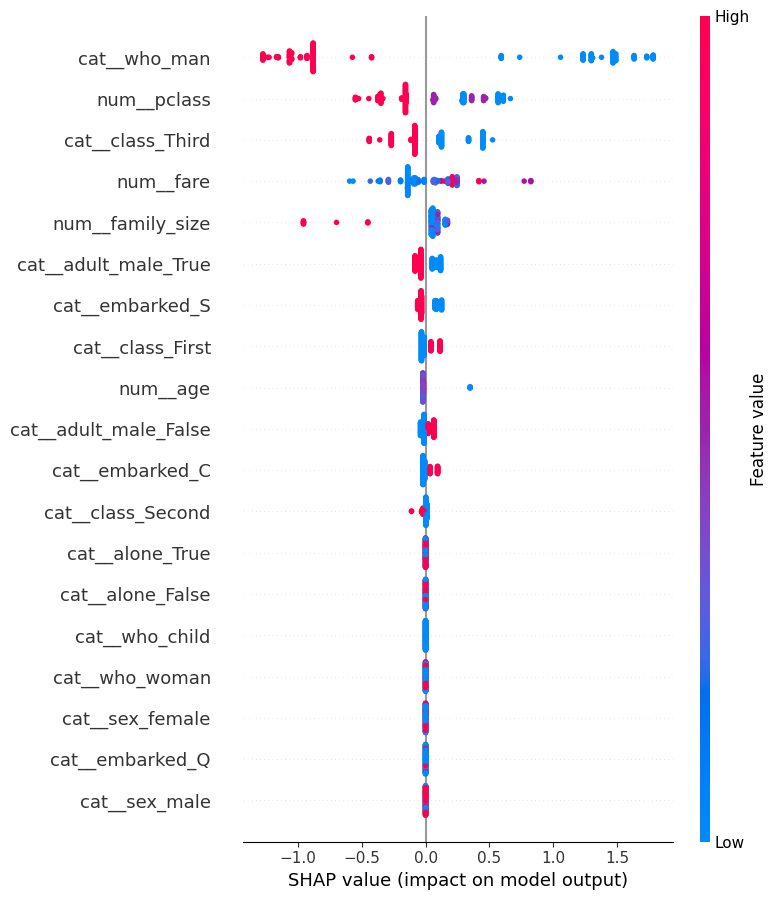

In [ ]:
shap.summary_plot(shap_values, x_test_transformed, feature_names=feature_names)
plt.show()

**Graph 1: Summary Plot (Complete models behaviour)**
* It tells us about the enitre model logic
* The feature that are at the top are the most important feature
* If dots moving to the left pushed --> Did not survived
* dots moving to the right pushed the prediction towards -> survived


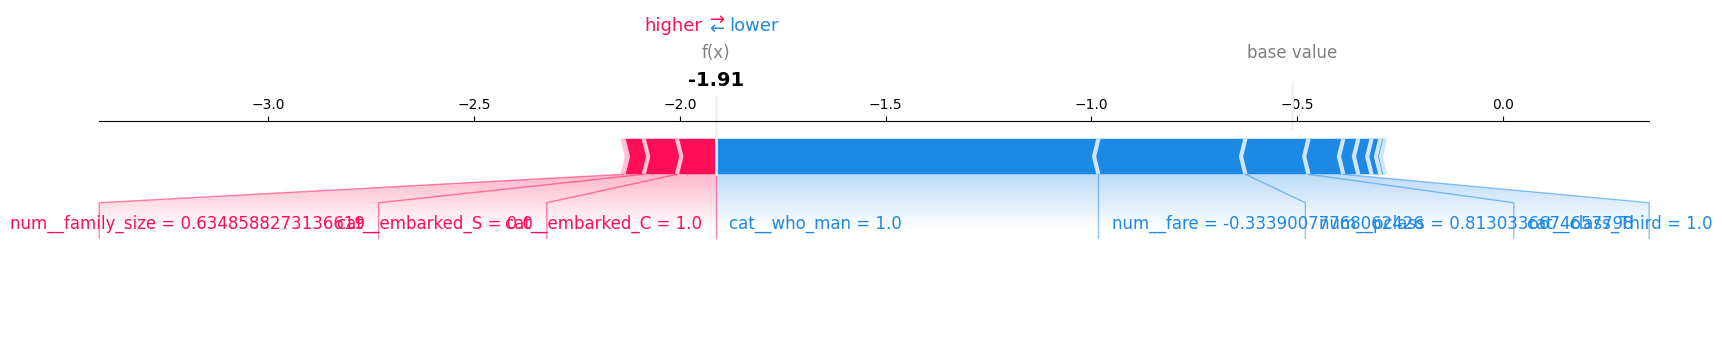

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    pd.DataFrame(x_test_transformed,columns=feature_names).iloc[0,:],
    matplotlib = True
)

plt.show()

**Graph 2: Force Plot (A single Prediction)**
* It tells you the prediction for one specific peroson
* The models final pred -> 1.99 (did not survive)
* Red arrow -> The reason for survived
* Blue Arrow -> Reason for not survuved
* THe reason why the passenger was predicted not to survive is that they were a man. THe single factor was stronger than all other factors

Miro : https://miro.com/app/board/uXjVJ4No-g8=/?share_link_id=164220003004